In [438]:
import pandas as pd


In [439]:
meta_features = pd.read_csv("data/meta_features_with_descriptions.csv").set_index("video_id")
meta_features.drop(columns=['description'],inplace=True)
# for every meta_feature, rename the column starting with "meta_"
meta_features.columns = ["meta_" + col for col in meta_features.columns]
transcript_features = pd.read_csv("data/transcript_feature_complete.csv").set_index("video_id")

merged = meta_features.merge(transcript_features, on='video_id', how='left')
merged.to_csv("data/integrated_features.csv", index=True)

In [440]:


# labelling_group1.xlsx - sheet "1-50"
res1_1 = pd.read_excel("data/labelling_group1.xlsx", sheet_name="1-50")
res1_1 = res1_1.set_index(["video_id"]).sort_index()
res1_1 = res1_1.loc[:, ["Understandability SCore"]]

# labelling_group1.xlsx - sheet "51-200"
res1_2 = pd.read_excel("data/labelling_group1.xlsx", sheet_name="51-200")
res1_2 = res1_2.set_index(["video_id"]).sort_index()
res1_2 = res1_2.loc[:, ["Understandability SCore"]]

res1 = pd.concat([res1_1, res1_2])
# Remove duplicates by index (video_id), keep last occurrence
res1 = res1[~res1.index.duplicated(keep='last')]

# labelling_group2.xlsx
# sheet "1-50" has header in second row (first row is empty)
res2_1 = pd.read_excel("data/labelling_group2.xlsx", header=1, sheet_name="1-50")
res2_1 = res2_1.set_index(["video_id"]).sort_index()
res2_1 = res2_1.loc[:, ["Understandability SCore"]]

# sheet "51-200" has header in first row
res2_2 = pd.read_excel("data/labelling_group2.xlsx", header=0, sheet_name="51-200")
res2_2 = res2_2.set_index(["video_id"]).sort_index()
res2_2 = res2_2.loc[:, ["Understandability SCore"]]

res2 = pd.concat([res2_1, res2_2])
# Remove duplicates by index (video_id), keep last occurrence
res2 = res2[~res2.index.duplicated(keep='last')]

res1 = res1[["Understandability SCore"]].rename(columns={"Understandability SCore": "score_group1"})
res2 = res2[["Understandability SCore"]].rename(columns={"Understandability SCore": "score_group2"})


In [441]:
# Merge res1 and res2 on video_id (which is the index)
# Since both DataFrames have video_id as index, use left_index and right_index
labels = res1.merge(res2, left_index=True, right_index=True, how="left")

# Replace '#DIV/0!' with NaN before converting to float
labels.loc[labels['score_group1'] == '#DIV/0!', 'score_group1'] = 0
labels.loc[labels['score_group2'] == '#DIV/0!', 'score_group2'] = 0

# Convert to float (None/NaN will be preserved)
labels['score_group1'] = pd.to_numeric(labels['score_group1'], errors='coerce')
labels['score_group2'] = pd.to_numeric(labels['score_group2'], errors='coerce')

# Calculate difference
labels["difference"] = labels["score_group1"] - labels["score_group2"]
labels["difference"].describe()

count    190.000000
mean      -0.005969
std        0.088371
min       -0.318182
25%       -0.035354
50%        0.000000
75%        0.000000
max        0.400000
Name: difference, dtype: float64

In [442]:
mean_label = labels.loc[:,["score_group1", "score_group2"]].mean(axis=1).to_frame().rename(columns={0: "label"})


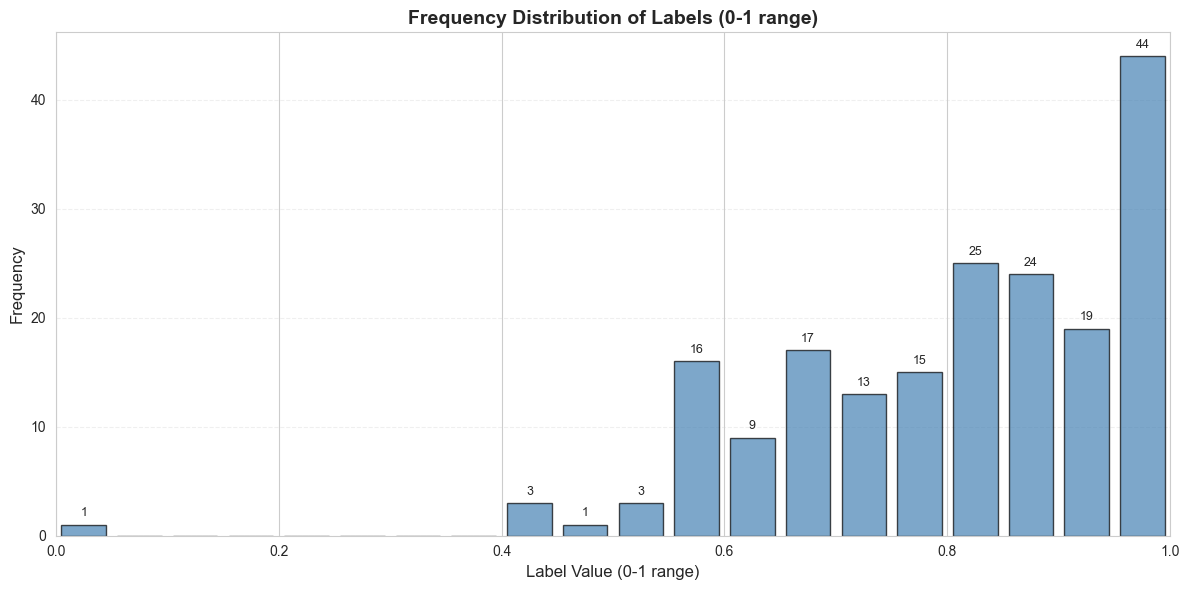

Total labels: 190
Valid labels (non-NaN): 190
Label range: [0.000, 1.000]

Frequency distribution (binned into 20 intervals):
  [0.00-0.05): 1
  [0.40-0.45): 3
  [0.45-0.50): 1
  [0.50-0.55): 3
  [0.55-0.60): 16
  [0.60-0.65): 9
  [0.65-0.70): 17
  [0.70-0.75): 13
  [0.75-0.80): 15
  [0.80-0.85): 25
  [0.85-0.90): 24
  [0.90-0.95): 19
  [0.95-1.00): 44


In [443]:
import matplotlib.pyplot as plt
import numpy as np

# Bin the labels into intervals from 0 to 1
# You can adjust the number of bins (e.g., 10, 20, etc.)
n_bins = 20
bins = np.linspace(0, 1, n_bins + 1)  # Create bins from 0 to 1

# Count frequencies for each bin
label_counts, bin_edges = np.histogram(mean_label["label"].dropna(), bins=bins)

# Create bin labels (midpoint of each bin)
bin_labels = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(bin_edges) - 1)]

# Create bar chart
plt.figure(figsize=(12, 6))
bars = plt.bar(bin_labels, label_counts, width=1/n_bins*0.8, 
               color='steelblue', edgecolor='black', alpha=0.7)

plt.xlabel('Label Value (0-1 range)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Frequency Distribution of Labels (0-1 range)', fontsize=14, fontweight='bold')
plt.xlim(0, 1)  # Set x-axis range to 0-1
plt.grid(axis='y', alpha=0.3, linestyle='--')

# Add value labels on top of bars (only for non-zero values)
for i, (label, count) in enumerate(zip(bin_labels, label_counts)):
    if count > 0:
        plt.text(label, count + 0.5, str(count), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


# Print summary statistics
print(f"Total labels: {len(mean_label)}")
print(f"Valid labels (non-NaN): {mean_label['label'].notna().sum()}")
print(f"Label range: [{mean_label['label'].min():.3f}, {mean_label['label'].max():.3f}]")
print(f"\nFrequency distribution (binned into {n_bins} intervals):")
for i in range(len(bin_labels)):
    if label_counts[i] > 0:
        print(f"  [{bin_edges[i]:.2f}-{bin_edges[i+1]:.2f}): {label_counts[i]}")

In [444]:
mean_label.reset_index(inplace=True)
mean_label.to_csv("data/label.csv", index=False)

In [ ]:
import random 
random.seed(42)

# get random 140 rows from mean_label
random_rows = mean_label.sample(n=140, random_state=42)
random_rows.to_csv("data/train_y.csv", index=False)

# Get video_ids from the sampled rows (video_id is a column after reset_index)
train_video_ids = random_rows["video_id"].tolist()

# get the rest of the rows (drop by video_id, not index)
test_rows = mean_label[~mean_label["video_id"].isin(train_video_ids)]
test_rows.to_csv("data/test_y.csv", index=False)
test_video_ids = test_rows["video_id"].tolist()

print(f"Train set: {len(train_video_ids)} videos")
print(f"Test set: {len(test_video_ids)} videos")
print(f"Total: {len(train_video_ids) + len(test_video_ids)} videos")


Initial split (before alignment):
Train set: 140 videos
Test set: 50 videos
Total: 190 videos

⚠️  Note: Final aligned split will be created in Cell 25
   after ensuring X and y are properly aligned by video_id


# Explatory Data Analytics

In [446]:
df = pd.read_csv("data/integrated_features.csv")
df.head()


,video_id,meta_has_title,meta_has_description,meta_video_duration,meta_description_length,meta_description_unique_words,meta_view_count,meta_like_count,meta_comment_count,meta_subscriber_count,...,other_ratio,passive_voice_ratio,average_sentence_length,sentence_length_std,syntax_tree_depth,subordinate_clause_density,average_dependency_distance,pronoun_frequency,text_length,word_count
0,--uQR16bKD8,True,True,5563.0,35,26,1654,27,0,191000,...,0.387755,0.394,42.69,46.18,7.15,0.006,3.93,0.148,76522.0,14427.0
1,-8wPY3vFR_A,True,True,291.0,59,44,3506,16,0,216000,...,0.086957,0.216,16.59,7.66,5.95,0.059,3.02,0.094,3965.0,612.0
2,-B-HaLGqQRM,True,True,74.0,43,38,263,0,0,7550,...,0.303030,0.000,59.33,19.86,11.33,0.407,3.61,0.174,872.0,170.0
3,-DGB139NQg8,True,True,151.0,22,21,91232,287,2,67000,...,0.000000,0.125,16.50,5.37,6.38,0.270,2.79,0.091,930.0,127.0
4,-DgvdrXc3ko,True,True,5349.0,100,80,1480,9,0,1100,...,0.531250,1.383,114.28,143.75,10.37,0.018,5.22,0.073,61512.0,10567.0


In [447]:
df.describe()

,meta_video_duration,meta_description_length,meta_description_unique_words,meta_view_count,meta_like_count,meta_comment_count,meta_subscriber_count,meta_channel_upload_count,meta_sentence_count,flesch_reading_ease,...,other_ratio,passive_voice_ratio,average_sentence_length,sentence_length_std,syntax_tree_depth,subordinate_clause_density,average_dependency_distance,pronoun_frequency,text_length,word_count
count,2593.000000,2593.000000,2593.000000,2.593000e+03,2593.000000,2593.000000,2.593000e+03,2593.000000,2593.000000,2592.000000,...,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000,2592.000000,2592.00000,2592.000000,2592.000000
mean,805.696876,88.683378,62.509063,4.009308e+04,257.106440,12.045507,1.897987e+05,2538.615889,4.719244,-1394.529954,...,0.426301,1.019853,92.897018,61.279167,9.003056,0.249341,4.080876,0.12155,10445.201003,1885.092978
std,1774.985502,92.895495,51.115361,4.714885e+05,3526.043476,125.689022,3.355557e+05,3052.854952,5.255788,3128.624650,...,0.237670,2.183334,141.438309,100.920141,4.449137,0.291427,1.733028,0.05167,19979.849970,3619.303943
min,8.000000,0.000000,0.000000,2.000000e+00,0.000000,0.000000,6.740000e+02,79.000000,0.000000,-27400.050000,...,0.000000,0.000000,1.500000,0.000000,2.000000,0.000000,1.000000,0.00000,11.000000,2.000000
25%,111.000000,34.000000,30.000000,4.360000e+02,3.000000,0.000000,1.540000e+04,696.000000,2.000000,-737.947500,...,0.285714,0.125000,17.857500,7.780000,6.000000,0.030750,3.070000,0.09575,1152.250000,204.750000
50%,203.000000,62.000000,51.000000,1.208000e+03,8.000000,0.000000,4.400000e+04,1417.000000,3.000000,-181.120000,...,0.440678,0.375000,45.890000,26.505000,7.720000,0.124000,3.680000,0.12500,2546.500000,462.000000
75%,532.000000,109.000000,78.000000,3.734000e+03,26.000000,1.000000,1.440000e+05,2838.000000,5.000000,53.575000,...,0.578947,1.000000,100.307500,77.772500,10.600000,0.357000,4.692500,0.15600,6587.250000,1190.000000
max,46148.000000,789.000000,395.000000,1.876906e+07,121597.000000,5067.000000,1.220000e+06,11882.000000,59.000000,99.690000,...,1.000000,30.000000,1742.000000,1124.300000,47.000000,0.990000,22.430000,0.28900,305894.000000,54795.000000


# Preprocessing Features

## Value Type

In [448]:
#map the sentiment to from 1 to 5
sentiment_mapping = {
    'Very Negative': 1,
    'Negative': 2,
    'Neutral': 3,
    'Positive': 4,
    'Very Positive': 5
}
df['meta_sentiment'] = df['meta_sentiment'].map(sentiment_mapping)
df['meta_sentiment'].value_counts()

meta_sentiment
3.0    2123
4.0     158
5.0     103
2.0      89
1.0       7
Name: count, dtype: int64

## Missing Values

1. MISSING VALUES ANALYSIS

⚠️  Features with missing values: 36
                              Missing Count  Missing Percentage
meta_sentiment                          113            4.357887
rare_term_ratio_mentions                  1            0.038565
context_ratio                             1            0.038565
term_clustering_max_share                 1            0.038565
condition_ratio                           1            0.038565
symptom_ratio                             1            0.038565
therapy_ratio                             1            0.038565
diagnostic_ratio                          1            0.038565
medication_ratio                          1            0.038565
anatomy_ratio                             1            0.038565
location_ratio                            1            0.038565
measurement_ratio                         1            0.038565
activity_ratio                            1            0.038565
term_clustering_concentrated           

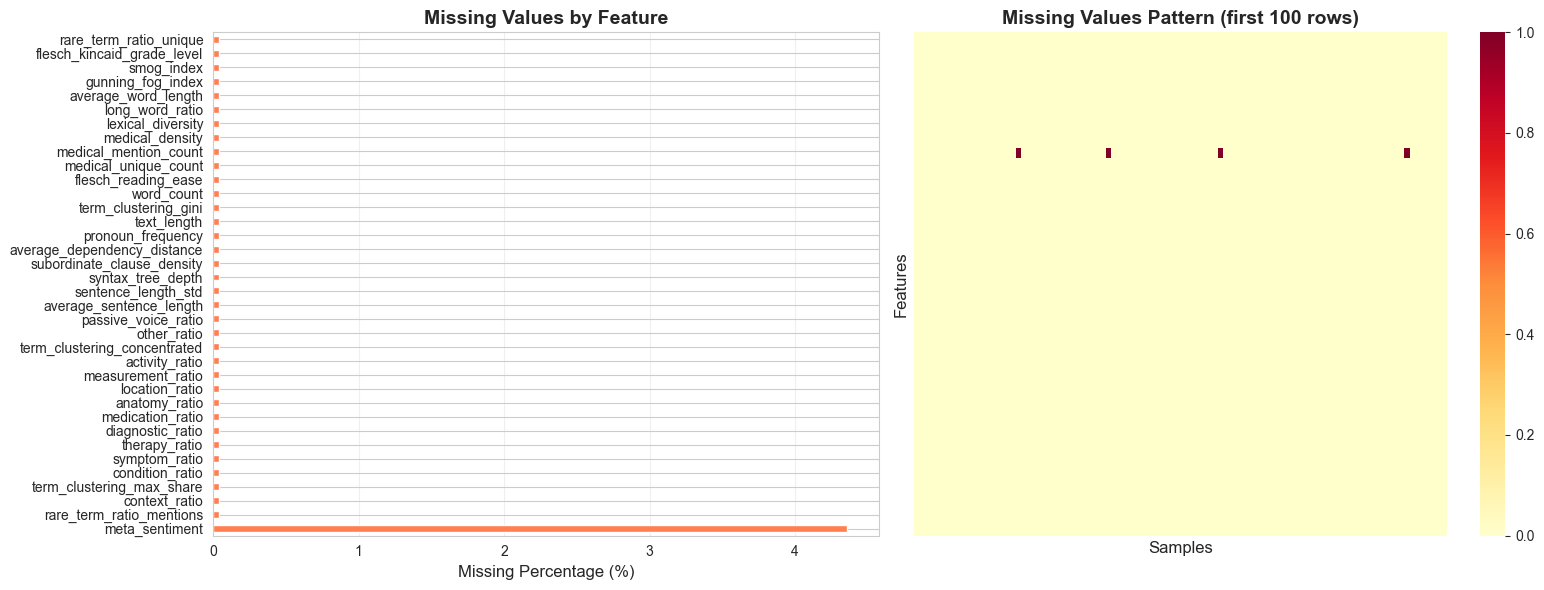


📊 Missing Values Statistics:
   Total missing values: 148
   Percentage of total data: 0.12%


In [449]:

# ============================================================================
# 1. MISSING VALUES ANALYSIS
# ============================================================================
print("=" * 80)
print("1. MISSING VALUES ANALYSIS")
print("=" * 80)

missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percent
}).sort_values('Missing Count', ascending=False)

# Filter to show only columns with missing values
missing_df = missing_df[missing_df['Missing Count'] > 0]

if len(missing_df) > 0:
    print(f"\n⚠️  Features with missing values: {len(missing_df)}")
    print(missing_df.to_string())
    
    # Visualize missing values - Multiple plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Bar chart
    missing_df['Missing Percentage'].plot(kind='barh', ax=axes[0], color='coral')
    axes[0].set_xlabel('Missing Percentage (%)', fontsize=12)
    axes[0].set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
    axes[0].grid(axis='x', alpha=0.3)
    
    # Plot 2: Missing values pattern heatmap (sample of data)
    sample_size = min(100, len(df))
    missing_sample = df.iloc[:sample_size].isnull()
    sns.heatmap(missing_sample.T, ax=axes[1], cbar=True, cmap='YlOrRd', 
                yticklabels=False, xticklabels=False)
    axes[1].set_title(f'Missing Values Pattern (first {sample_size} rows)', 
                      fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Features', fontsize=12)
    axes[1].set_xlabel('Samples', fontsize=12)
    
    plt.tight_layout()
    plt.show()
    
    # Additional statistics
    print(f"\n📊 Missing Values Statistics:")
    print(f"   Total missing values: {missing_data.sum()}")
    print(f"   Percentage of total data: {(missing_data.sum() / (df.shape[0] * df.shape[1])) * 100:.2f}%")
else:
    print("✅ No missing values found!")


In [450]:
df.dropna(inplace=True)

## Constant

In [451]:
# ============================================================================
# 2. CONSTANT AND NEAR-CONSTANT FEATURES
# ============================================================================
print("=" * 80)
print("2. CONSTANT AND NEAR-CONSTANT FEATURES")
print("=" * 80)

# Find constant features (zero variance)
constant_features = []
near_constant_features = []

numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if df[col].nunique() == 1:
        constant_features.append(col)
    elif df[col].nunique() == 2:
        # Check if one value dominates (>95%)
        value_counts = df[col].value_counts(normalize=True)
        if value_counts.max() > 0.95:
            near_constant_features.append((col, value_counts.max() * 100))

if constant_features:
    print(f"\n⚠️  Constant features (zero variance): {len(constant_features)}")
    print(constant_features)
else:
    print("\n✅ No constant features found")

if near_constant_features:
    print(f"\n⚠️  Near-constant features (>95% same value): {len(near_constant_features)}")
    near_const_df = pd.DataFrame(near_constant_features, columns=['Feature', 'Dominant_Value_Pct'])
    print(near_const_df.to_string(index=False))
    
    # Visualize near-constant features
    if len(near_constant_features) > 0:
        fig, ax = plt.subplots(figsize=(12, max(4, len(near_constant_features) * 0.4)))
        near_const_df_sorted = near_const_df.sort_values('Dominant_Value_Pct', ascending=True)
        ax.barh(near_const_df_sorted['Feature'], near_const_df_sorted['Dominant_Value_Pct'], 
                color='orange', alpha=0.7)
        ax.set_xlabel('Dominant Value Percentage (%)', fontsize=12)
        ax.set_title('Near-Constant Features (>95% same value)', fontsize=14, fontweight='bold')
        ax.axvline(x=95, color='red', linestyle='--', label='95% threshold')
        ax.legend()
        ax.grid(axis='x', alpha=0.3)
        plt.tight_layout()
        plt.show()
else:
    print("\n✅ No near-constant features found")


2. CONSTANT AND NEAR-CONSTANT FEATURES

⚠️  Constant features (zero variance): 2
['diagnostic_ratio', 'context_ratio']

✅ No near-constant features found


In [452]:
# drop the diagnostic_ratio and context_ratio as they are constant for all videos
print(df['diagnostic_ratio'].value_counts())
print(df['context_ratio'].value_counts())
df.drop(columns=['diagnostic_ratio', 'context_ratio'], inplace=True)


diagnostic_ratio
0.0    2479
Name: count, dtype: int64
context_ratio
0.0    2479
Name: count, dtype: int64


## Correlation 

4. CORRELATION ANALYSIS - Highly Correlated Features

⚠️  Found 26 highly correlated feature pairs (|r| >= 0.8):
                     Feature1                      Feature2  Correlation
   flesch_kincaid_grade_level             gunning_fog_index     1.000000
          flesch_reading_ease    flesch_kincaid_grade_level    -0.999997
          flesch_reading_ease             gunning_fog_index    -0.999997
                  text_length                    word_count     0.998915
      meta_description_length meta_description_unique_words     0.983121
        medical_mention_count          medical_unique_count     0.974005
         term_clustering_gini     term_clustering_max_share     0.958663
          flesch_reading_ease                    smog_index    -0.949067
                   smog_index             gunning_fog_index     0.948979
   flesch_kincaid_grade_level                    smog_index     0.948942
        meta_subscriber_count     meta_channel_upload_count     0.934734
           

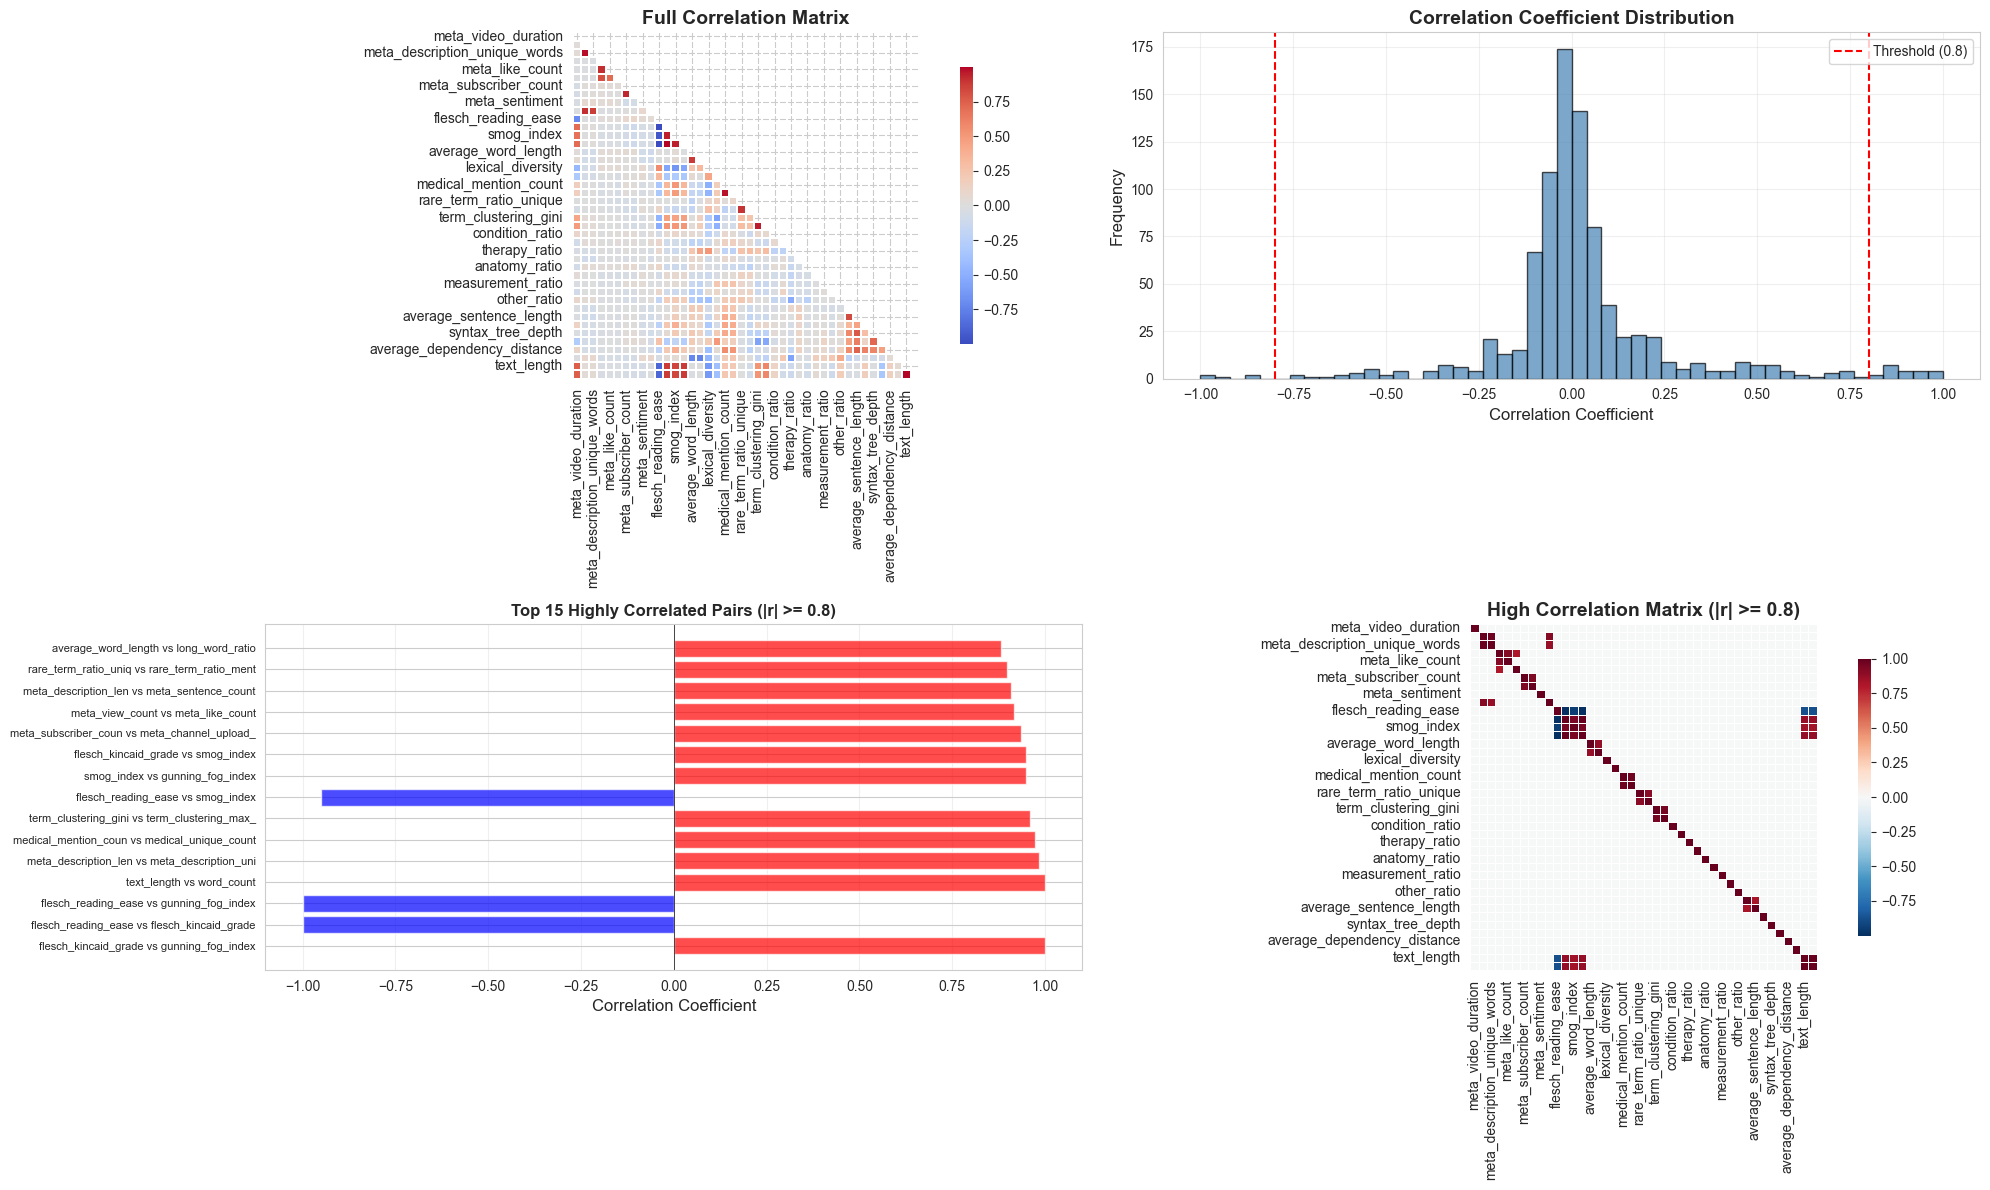


💡 Recommendation: Consider removing 15 features
   (lower variance features from highly correlated pairs):
   ['long_word_ratio', 'flesch_reading_ease', 'meta_channel_upload_count', 'rare_term_ratio_unique', 'passive_voice_ratio', 'meta_like_count', 'meta_description_unique_words', 'term_clustering_gini', 'word_count', 'flesch_kincaid_grade_level', 'gunning_fog_index', 'medical_unique_count', 'smog_index', 'meta_comment_count', 'meta_sentence_count']...


In [453]:
# ============================================================================
# 4. CORRELATION ANALYSIS - Highly Correlated Features
# ============================================================================
print("=" * 80)
print("4. CORRELATION ANALYSIS - Highly Correlated Features")
print("=" * 80)

# Calculate correlation matrix for numeric features only
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Find highly correlated pairs (|correlation| > 0.8)
high_corr_threshold = 0.8
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) >= high_corr_threshold:
            high_corr_pairs.append({
                'Feature1': corr_matrix.columns[i],
                'Feature2': corr_matrix.columns[j],
                'Correlation': corr_val
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(f"\n⚠️  Found {len(high_corr_pairs)} highly correlated feature pairs (|r| >= {high_corr_threshold}):")
    print(high_corr_df.to_string(index=False))
    
    # Enhanced visualizations
    fig = plt.figure(figsize=(20, 12))
    
    # Plot 1: Full correlation matrix heatmap
    ax1 = plt.subplot(2, 2, 1)
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.1, cbar_kws={"shrink": 0.8}, ax=ax1, fmt='.2f')
    ax1.set_title('Full Correlation Matrix', fontsize=14, fontweight='bold')
    
    # Plot 2: Correlation distribution histogram
    ax2 = plt.subplot(2, 2, 2)
    corr_values = corr_matrix.values[np.triu_indices_from(corr_matrix.values, k=1)]
    ax2.hist(corr_values, bins=50, color='steelblue', alpha=0.7, edgecolor='black')
    ax2.axvline(x=high_corr_threshold, color='red', linestyle='--', label=f'Threshold ({high_corr_threshold})')
    ax2.axvline(x=-high_corr_threshold, color='red', linestyle='--')
    ax2.set_xlabel('Correlation Coefficient', fontsize=12)
    ax2.set_ylabel('Frequency', fontsize=12)
    ax2.set_title('Correlation Coefficient Distribution', fontsize=14, fontweight='bold')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    # Plot 3: Top correlated pairs bar chart
    ax3 = plt.subplot(2, 2, 3)
    top_pairs = high_corr_df.head(15)
    pair_labels = [f"{row['Feature1'][:15]}...\nvs\n{row['Feature2'][:15]}..." 
                   for _, row in top_pairs.iterrows()]
    colors = ['red' if x > 0 else 'blue' for x in top_pairs['Correlation']]
    ax3.barh(range(len(top_pairs)), top_pairs['Correlation'], color=colors, alpha=0.7)
    ax3.set_yticks(range(len(top_pairs)))
    ax3.set_yticklabels([f"{row['Feature1'][:20]} vs {row['Feature2'][:20]}" 
                         for _, row in top_pairs.iterrows()], fontsize=8)
    ax3.set_xlabel('Correlation Coefficient', fontsize=12)
    ax3.set_title(f'Top 15 Highly Correlated Pairs (|r| >= {high_corr_threshold})', 
                  fontsize=12, fontweight='bold')
    ax3.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax3.grid(axis='x', alpha=0.3)
    
    # Plot 4: Correlation network (simplified - only top correlations)
    ax4 = plt.subplot(2, 2, 4)
    # Create a simplified correlation matrix showing only high correlations
    high_corr_matrix = corr_matrix.copy()
    high_corr_matrix[abs(high_corr_matrix) < high_corr_threshold] = 0
    sns.heatmap(high_corr_matrix, annot=False, cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax4, fmt='.2f')
    ax4.set_title(f'High Correlation Matrix (|r| >= {high_corr_threshold})', 
                  fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Identify features to potentially remove
    features_to_consider_removing = set()
    for _, row in high_corr_df.iterrows():
        var1 = numeric_df[row['Feature1']].var()
        var2 = numeric_df[row['Feature2']].var()
        if var1 < var2:
            features_to_consider_removing.add(row['Feature1'])
        else:
            features_to_consider_removing.add(row['Feature2'])
    
    print(f"\n💡 Recommendation: Consider removing {len(features_to_consider_removing)} features")
    print(f"   (lower variance features from highly correlated pairs):")
    print(f"   {list(features_to_consider_removing)[:15]}...")
else:
    print(f"\n✅ No highly correlated features found (threshold: |r| >= {high_corr_threshold})")
    
    # Still show correlation matrix
    plt.figure(figsize=(14, 12))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', center=0,
                square=True, linewidths=0.1, cbar_kws={"shrink": 0.8}, fmt='.2f')
    plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()


In [454]:


# Decision: Which features to keep and which to remove?
# For readability metrics:
# - flesch_reading_ease: Most commonly used, interpretable (higher score = easier to read)
# - flesch_kincaid_grade_level: Grade level (lower is better)
# - gunning_fog_index: Grade level (lower is better)
# 
# Since flesch_reading_ease is most interpretable and commonly used, we'll keep it
# and remove the other two (they provide redundant information)

features_to_remove = ['flesch_kincaid_grade_level', 
                      'gunning_fog_index',
                      "flesch_reading_ease",
                      "smog_index"]
df = df.drop(columns=features_to_remove)
    
features_to_remove = [
    "text_length",
    "meta_description_length",
    "medical_unique_count",
    "term_clustering_max_share",
    "meta_channel_upload_count",
    "meta_view_count",
    "meta_description_length",
    "rare_term_ratio_mentions",
    "long_word_ratio",
    "meta_sentence_count",
    "average_sentence_length"
]
df = df.drop(columns=features_to_remove)

    


In [455]:

# Calculate correlation matrix for numeric features only
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# Find highly correlated pairs (|correlation| > 0.8)
high_corr_threshold = 0.7
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_val = corr_matrix.iloc[i, j]
        if abs(corr_val) >= high_corr_threshold:
            high_corr_pairs.append({
                'Feature1': corr_matrix.columns[i],
                'Feature2': corr_matrix.columns[j],
                'Correlation': corr_val
            })
            
print(pd.DataFrame(high_corr_pairs))      

              Feature1                    Feature2  Correlation
0  meta_video_duration                  word_count     0.753185
1  average_word_length           pronoun_frequency    -0.720683
2    syntax_tree_depth  subordinate_clause_density     0.722804


In [456]:
df.columns


Index(['video_id', 'meta_has_title', 'meta_has_description',
       'meta_video_duration', 'meta_description_unique_words',
       'meta_like_count', 'meta_comment_count', 'meta_subscriber_count',
       'meta_sentiment', 'average_word_length', 'lexical_diversity',
       'medical_density', 'medical_mention_count', 'rare_term_ratio_unique',
       'term_clustering_concentrated', 'term_clustering_gini',
       'condition_ratio', 'symptom_ratio', 'therapy_ratio', 'medication_ratio',
       'anatomy_ratio', 'location_ratio', 'measurement_ratio',
       'activity_ratio', 'other_ratio', 'passive_voice_ratio',
       'sentence_length_std', 'syntax_tree_depth',
       'subordinate_clause_density', 'average_dependency_distance',
       'pronoun_frequency', 'word_count'],
      dtype='object')

In [ ]:
x_train_unscaled = df[df['video_id'].isin(train_video_ids)]
print(f"✅ Training data shape: {train_df.shape}")
print(f"   Number of training samples: {len(train_df)}")
print(f"   Columns: {train_df.shape[1]}")

# Testing data - filter rows where video_id is in test_video_ids
x_test_unscaled = df[df['video_id'].isin(test_video_ids)]
print(f"\n✅ Testing data shape: {test_df.shape}")
print(f"   Number of testing samples: {len(test_df)}")
print(f"   Columns: {test_df.shape[1]}")


x_train_unscaled.to_csv("data/x_train_unscaled.csv", index=True)
x_test_unscaled.to_csv("data/x_test_unscaled.csv", index=True)

DATA SPLIT: Creating Train/Test Sets (UNSCALED)

📊 Video ID Alignment:
   Features (df): 2479 video_ids
   Labels: 190 video_ids
   Common (both): 182 video_ids

📊 Train/Test Split (Aligned):
   Train: 140 video_ids
   Test: 42 video_ids
   Total: 182 video_ids

✅ Verification:
   x_train_unscaled: 140 samples, 32 features
   y_train: 140 samples
   x_test_unscaled: 42 samples, 32 features
   y_test: 42 samples

   Train video_ids match: True
   Test video_ids match: True

💾 Saved unscaled data:
   • data/x_train_unscaled.csv
   • data/x_test_unscaled.csv
   • data/train_y.csv
   • data/test_y.csv



## Scale

3. SCALE ANALYSIS - Feature Ranges and Scales

📊 Feature Scale Summary (Top 20 by range):
                      Feature     Min         Max       Range          Mean           Std Scale_Type
        meta_subscriber_count 674.000 1220000.000 1219326.000 196055.532876 341117.822737      Large
              meta_like_count   0.000  121597.000  121597.000    261.607503   3602.654776      Large
          meta_video_duration   8.000   46148.000   46140.000    798.419524   1661.322314      Large
                   word_count   2.000   40965.000   40963.000   1880.237999   3469.218894      Large
           meta_comment_count   0.000    5067.000    5067.000     12.396531    128.473771      Large
          sentence_length_std   0.000    1124.300    1124.300     59.874441     98.821976      Large
meta_description_unique_words   3.000     395.000     392.000     65.368294     50.462233     Medium
        medical_mention_count   0.000     138.000     138.000     38.795885     29.370354     Medium
 

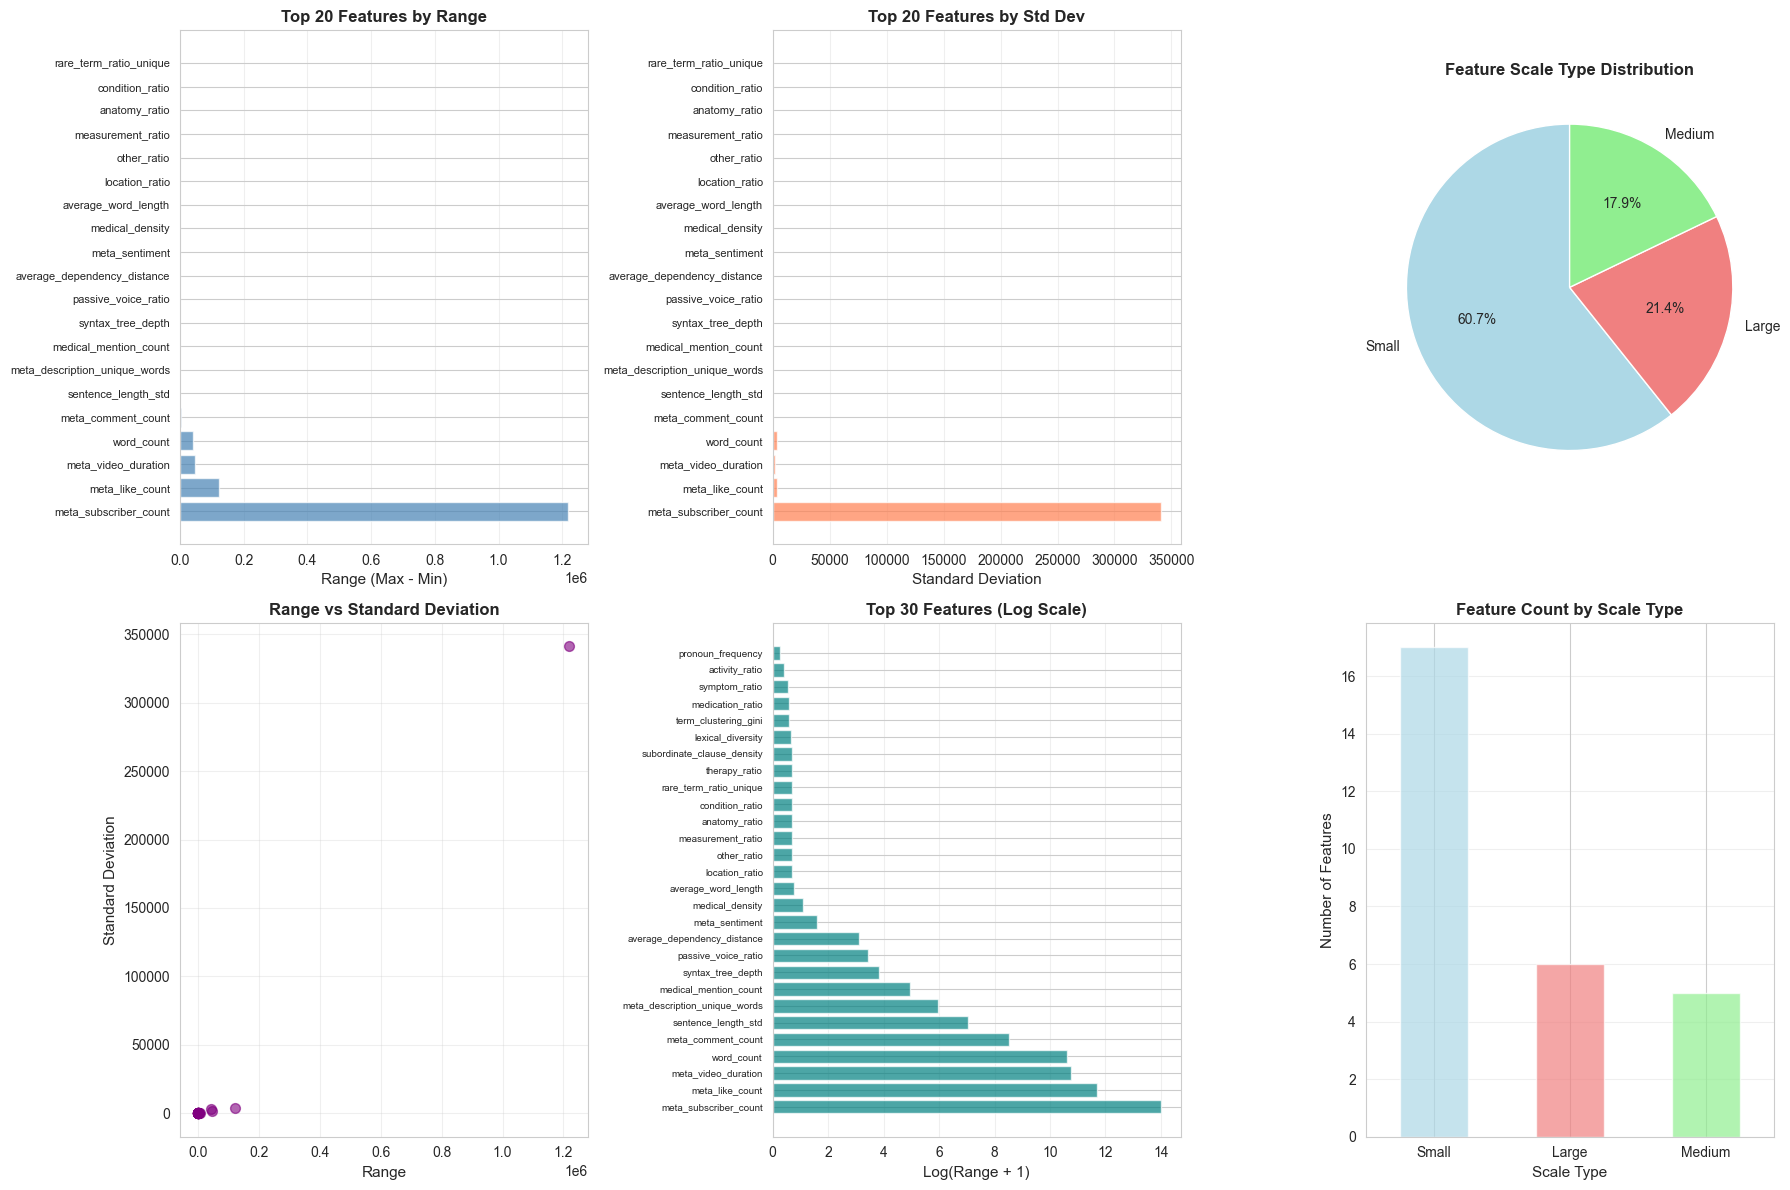


📊 Scale Type Summary:
   Large scale (|value| > 1000): 6 features
   Medium scale (10 < |value| <= 1000): 5 features
   Small scale (|value| <= 10): 17 features

⚠️  Features with LARGE scale (consider normalization):
   ['meta_subscriber_count', 'meta_like_count', 'meta_video_duration', 'word_count', 'meta_comment_count', 'sentence_length_std']

✅ Features with SMALL scale (likely normalized):
   ['meta_sentiment', 'medical_density', 'average_word_length', 'location_ratio', 'other_ratio', 'measurement_ratio', 'anatomy_ratio', 'condition_ratio', 'rare_term_ratio_unique', 'therapy_ratio']... (17 total)


In [458]:
# ============================================================================
# 3. SCALE ANALYSIS - Feature Ranges and Scales
# ============================================================================
print("=" * 80)
print("3. SCALE ANALYSIS - Feature Ranges and Scales")
print("=" * 80)

scale_info = []
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    col_data = df[col].dropna()
    if len(col_data) > 0:
        min_val = col_data.min()
        max_val = col_data.max()
        mean_val = col_data.mean()
        std_val = col_data.std()
        scale_info.append({
            'Feature': col,
            'Min': min_val,
            'Max': max_val,
            'Range': max_val - min_val,
            'Mean': mean_val,
            'Std': std_val,
            'Scale_Type': 'Large' if abs(max_val) > 1000 or abs(min_val) > 1000 else 
                         'Medium' if abs(max_val) > 10 or abs(min_val) > 10 else 'Small'
        })

scale_df = pd.DataFrame(scale_info).sort_values('Range', ascending=False)

print("\n📊 Feature Scale Summary (Top 20 by range):")
print(scale_df.head(20).to_string(index=False))

# Enhanced visualizations
fig = plt.figure(figsize=(18, 12))

# Plot 1: Range of features
ax1 = plt.subplot(2, 3, 1)
top_20 = scale_df.head(20)
ax1.barh(range(len(top_20)), top_20['Range'], color='steelblue', alpha=0.7)
ax1.set_yticks(range(len(top_20)))
ax1.set_yticklabels(top_20['Feature'], fontsize=8)
ax1.set_xlabel('Range (Max - Min)', fontsize=11)
ax1.set_title('Top 20 Features by Range', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Standard deviation
ax2 = plt.subplot(2, 3, 2)
ax2.barh(range(len(top_20)), top_20['Std'], color='coral', alpha=0.7)
ax2.set_yticks(range(len(top_20)))
ax2.set_yticklabels(top_20['Feature'], fontsize=8)
ax2.set_xlabel('Standard Deviation', fontsize=11)
ax2.set_title('Top 20 Features by Std Dev', fontsize=12, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Plot 3: Scale type distribution
ax3 = plt.subplot(2, 3, 3)
scale_type_counts = scale_df['Scale_Type'].value_counts()
ax3.pie(scale_type_counts.values, labels=scale_type_counts.index, autopct='%1.1f%%',
        colors=['lightblue', 'lightcoral', 'lightgreen'], startangle=90)
ax3.set_title('Feature Scale Type Distribution', fontsize=12, fontweight='bold')

# Plot 4: Range vs Std scatter
ax4 = plt.subplot(2, 3, 4)
ax4.scatter(scale_df['Range'], scale_df['Std'], alpha=0.6, s=50, c='purple')
ax4.set_xlabel('Range', fontsize=11)
ax4.set_ylabel('Standard Deviation', fontsize=11)
ax4.set_title('Range vs Standard Deviation', fontsize=12, fontweight='bold')
ax4.grid(alpha=0.3)

# Plot 5: Log scale range (for better visualization)
ax5 = plt.subplot(2, 3, 5)
top_30 = scale_df.head(30)
ax5.barh(range(len(top_30)), np.log1p(top_30['Range']), color='teal', alpha=0.7)
ax5.set_yticks(range(len(top_30)))
ax5.set_yticklabels(top_30['Feature'], fontsize=7)
ax5.set_xlabel('Log(Range + 1)', fontsize=11)
ax5.set_title('Top 30 Features (Log Scale)', fontsize=12, fontweight='bold')
ax5.grid(axis='x', alpha=0.3)

# Plot 6: Scale type by feature count
ax6 = plt.subplot(2, 3, 6)
scale_type_counts.plot(kind='bar', ax=ax6, color=['lightblue', 'lightcoral', 'lightgreen'], alpha=0.7)
ax6.set_ylabel('Number of Features', fontsize=11)
ax6.set_xlabel('Scale Type', fontsize=11)
ax6.set_title('Feature Count by Scale Type', fontsize=12, fontweight='bold')
ax6.grid(axis='y', alpha=0.3)
ax6.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Identify features with very different scales
large_scale = scale_df[scale_df['Scale_Type'] == 'Large']
small_scale = scale_df[scale_df['Scale_Type'] == 'Small']
medium_scale = scale_df[scale_df['Scale_Type'] == 'Medium']

print(f"\n📊 Scale Type Summary:")
print(f"   Large scale (|value| > 1000): {len(large_scale)} features")
print(f"   Medium scale (10 < |value| <= 1000): {len(medium_scale)} features")
print(f"   Small scale (|value| <= 10): {len(small_scale)} features")

if len(large_scale) > 0:
    print(f"\n⚠️  Features with LARGE scale (consider normalization):")
    print(f"   {list(large_scale['Feature'])}")

if len(small_scale) > 0:
    print(f"\n✅ Features with SMALL scale (likely normalized):")
    print(f"   {list(small_scale['Feature'])[:10]}... ({len(small_scale)} total)")


In [459]:
# ============================================================================
# HOW TO HANDLE LARGE AND MEDIUM SCALE FEATURES
# ============================================================================
# For Logistic Regression, we need to scale features to similar ranges
# ============================================================================

print("=" * 80)
print("HOW TO HANDLE LARGE AND MEDIUM SCALE FEATURES")
print("=" * 80)

# Get features that need scaling
features_to_scale_large = list(large_scale['Feature']) if len(large_scale) > 0 else []
features_to_scale_medium = list(medium_scale['Feature']) if len(medium_scale) > 0 else []
features_to_scale_all = features_to_scale_large + features_to_scale_medium

print(f"\n📊 Features Requiring Scaling:")
print(f"   • Large scale features: {len(features_to_scale_large)}")
print(f"   • Medium scale features: {len(features_to_scale_medium)}")
print(f"   • Total features to scale: {len(features_to_scale_all)}")

if len(features_to_scale_all) > 0:
    print(f"\n📋 Features to Scale:")
    print(f"   Large Scale ({len(features_to_scale_large)}):")
    for i, feat in enumerate(features_to_scale_large, 1):
        print(f"      {i:2d}. {feat}")
    
    if len(features_to_scale_medium) > 0:
        print(f"\n   Medium Scale ({len(features_to_scale_medium)}):")
        for i, feat in enumerate(features_to_scale_medium, 1):
            print(f"      {i:2d}. {feat}")

print("\n" + "=" * 80)
print("RECOMMENDED SCALING METHODS FOR LOGISTIC REGRESSION")
print("=" * 80)

print("\n💡 Method 1: StandardScaler (Z-score Normalization) - RECOMMENDED")
print("   ✅ Best for: Most cases, especially when features are normally distributed")
print("   Formula: (x - mean) / std")
print("   Result: Mean = 0, Std = 1")
print("   Pros: Preserves distribution shape, handles outliers reasonably")
print("   Cons: Sensitive to outliers")
print("\n   Usage:")
print("   from sklearn.preprocessing import StandardScaler")
print("   scaler = StandardScaler()")
print("   X_scaled = scaler.fit_transform(X[features_to_scale])")

print("\n💡 Method 2: RobustScaler (IQR-based)")
print("   ✅ Best for: Features with many outliers")
print("   Formula: (x - median) / IQR")
print("   Result: Median = 0, IQR = 1")
print("   Pros: Robust to outliers, less affected by extreme values")
print("   Cons: May not center data at 0")
print("\n   Usage:")
print("   from sklearn.preprocessing import RobustScaler")
print("   scaler = RobustScaler()")
print("   X_scaled = scaler.fit_transform(X[features_to_scale])")

print("\n💡 Method 3: MinMaxScaler (0-1 Normalization)")
print("   ✅ Best for: When you need bounded range [0, 1]")
print("   Formula: (x - min) / (max - min)")
print("   Result: Range [0, 1]")
print("   Pros: Bounded range, preserves relationships")
print("   Cons: Sensitive to outliers, may compress normal values")
print("\n   Usage:")
print("   from sklearn.preprocessing import MinMaxScaler")
print("   scaler = MinMaxScaler()")
print("   X_scaled = scaler.fit_transform(X[features_to_scale])")

print("\n💡 Method 4: Log Transformation (for highly skewed features)")
print("   ✅ Best for: Features with exponential distribution (e.g., view_count)")
print("   Formula: log(x + 1) or log1p(x)")
print("   Result: Reduces skewness, compresses large values")
print("   Pros: Handles extreme values well, can normalize skewed distributions")
print("   Cons: Only works for positive values, changes interpretation")
print("\n   Usage:")
print("   import numpy as np")
print("   X_log = np.log1p(X[features_to_scale])")

print("\n" + "=" * 80)
print("RECOMMENDATION FOR YOUR DATA")
print("=" * 80)
print("\n🎯 For Logistic Regression, I recommend:")
print("   1. Use StandardScaler for most features (Large + Medium scale)")
print("   2. Consider RobustScaler if you have many outliers")
print("   3. Apply log transformation to highly skewed count features:")
print("      - meta_view_count, meta_like_count, meta_comment_count")
print("      - word_count, text_length")
print("   4. Then apply StandardScaler after log transformation")

print("\n📝 Implementation Strategy:")
print("   Step 1: Identify skewed features (check skewness > 2)")
print("   Step 2: Apply log1p() to skewed count features")
print("   Step 3: Apply StandardScaler to all Large + Medium scale features")
print("   Step 4: Keep Small scale features as-is (already normalized)")

print("\n" + "=" * 80)
print("READY TO IMPLEMENT SCALING")
print("=" * 80)
print(f"\n✅ You have {len(features_to_scale_all)} features that need scaling")
print("   See next cells for implementation examples")


HOW TO HANDLE LARGE AND MEDIUM SCALE FEATURES

📊 Features Requiring Scaling:
   • Large scale features: 6
   • Medium scale features: 5
   • Total features to scale: 11

📋 Features to Scale:
   Large Scale (6):
       1. meta_subscriber_count
       2. meta_like_count
       3. meta_video_duration
       4. word_count
       5. meta_comment_count
       6. sentence_length_std

   Medium Scale (5):
       1. meta_description_unique_words
       2. medical_mention_count
       3. syntax_tree_depth
       4. passive_voice_ratio
       5. average_dependency_distance

RECOMMENDED SCALING METHODS FOR LOGISTIC REGRESSION

💡 Method 1: StandardScaler (Z-score Normalization) - RECOMMENDED
   ✅ Best for: Most cases, especially when features are normally distributed
   Formula: (x - mean) / std
   Result: Mean = 0, Std = 1
   Pros: Preserves distribution shape, handles outliers reasonably
   Cons: Sensitive to outliers

   Usage:
   from sklearn.preprocessing import StandardScaler
   scaler = Stan

IMPLEMENTATION: Apply Scaling to Features

📊 Step 1: Identifying Highly Skewed Features
--------------------------------------------------------------------------------

⚠️  Found 4 highly skewed features (|skewness| > 1):
   meta_like_count                    : skewness =    29.47
   meta_comment_count                 : skewness =    27.90
   word_count                         : skewness =     3.01
   meta_subscriber_count              : skewness =     2.15

📝 Applying log1p() transformation to 4 features...
   ✅ Applied log1p() to meta_like_count
   ✅ Applied log1p() to meta_comment_count
   ✅ Applied log1p() to word_count
   ✅ Applied log1p() to meta_subscriber_count

📊 Step 2: Applying StandardScaler to Large + Medium Scale Features
--------------------------------------------------------------------------------

📋 Scaling 11 features...
   ✅ Successfully scaled 11 features

📊 Verification - Scaled Features Statistics:
                                       mean       std       min

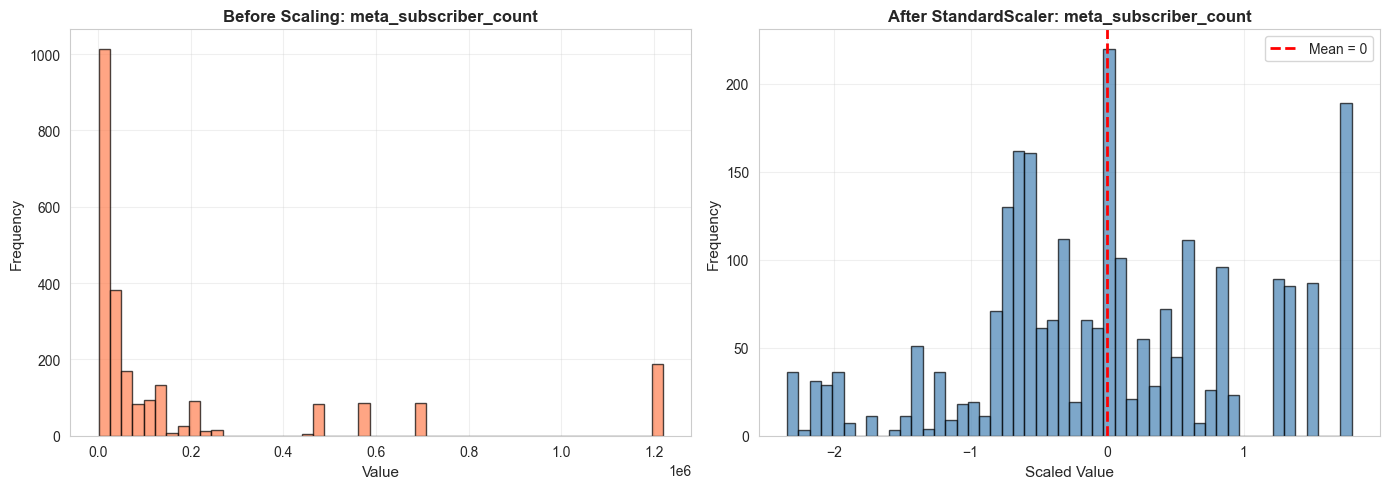


SCALING COMPLETE!

📝 Summary:
   • Applied log1p() to 4 skewed features
   • Applied StandardScaler to 11 features
   • Small scale features kept as-is

✅ Scaled dataframe stored in: df_scaled
   Ready for Logistic Regression!


In [460]:
# ============================================================================
# IMPLEMENTATION: Apply Scaling to Large and Medium Scale Features
# ============================================================================
# This cell demonstrates how to actually scale the features
# ============================================================================

from sklearn.preprocessing import StandardScaler, RobustScaler
from scipy import stats

print("=" * 80)
print("IMPLEMENTATION: Apply Scaling to Features")
print("=" * 80)

# Create a copy for scaling
df_scaled = df.copy()

# Step 1: Identify highly skewed features that should use log transformation first
print("\n📊 Step 1: Identifying Highly Skewed Features")
print("-" * 80)

skewed_features_for_log = []
count_features = ['meta_view_count', 'meta_like_count', 'meta_comment_count', 
                  'word_count', 'text_length', 'meta_subscriber_count',
                  'meta_channel_upload_count', 'medical_mention_count', 'medical_unique_count']

for feat in count_features:
    if feat in df.columns:
        col_data = df[feat].dropna()
        if len(col_data) > 0 and col_data.min() >= 0:  # Log only works for non-negative
            skewness = stats.skew(col_data)
            if abs(skewness) > 1:  # Highly skewed
                skewed_features_for_log.append((feat, skewness))

if skewed_features_for_log:
    print(f"\n⚠️  Found {len(skewed_features_for_log)} highly skewed features (|skewness| > 1):")
    for feat, skew in sorted(skewed_features_for_log, key=lambda x: abs(x[1]), reverse=True):
        print(f"   {feat:35s}: skewness = {skew:8.2f}")
    
    # Apply log transformation to skewed count features
    print(f"\n📝 Applying log1p() transformation to {len(skewed_features_for_log)} features...")
    for feat, _ in skewed_features_for_log:
        if feat in df_scaled.columns:
            df_scaled[feat] = np.log1p(df_scaled[feat])
            print(f"   ✅ Applied log1p() to {feat}")
else:
    print("   ✅ No highly skewed features found that need log transformation")

# Step 2: Apply StandardScaler to Large and Medium scale features
print(f"\n📊 Step 2: Applying StandardScaler to Large + Medium Scale Features")
print("-" * 80)

if len(features_to_scale_all) > 0:
    # Filter to only features that exist in dataframe
    features_to_scale_existing = [f for f in features_to_scale_all if f in df_scaled.columns]
    
    print(f"\n📋 Scaling {len(features_to_scale_existing)} features...")
    
    # Initialize scaler
    scaler = StandardScaler()
    
    # Apply scaling
    df_scaled[features_to_scale_existing] = scaler.fit_transform(df_scaled[features_to_scale_existing])
    
    print(f"   ✅ Successfully scaled {len(features_to_scale_existing)} features")
    
    # Verify scaling results
    print(f"\n📊 Verification - Scaled Features Statistics:")
    scaled_stats = df_scaled[features_to_scale_existing].describe().T[['mean', 'std', 'min', 'max']]
    print(scaled_stats.head(10))
    
    print(f"\n✅ Expected after StandardScaler:")
    print(f"   • Mean should be close to 0 (actual: {scaled_stats['mean'].abs().max():.6f})")
    print(f"   • Std should be close to 1 (actual range: [{scaled_stats['std'].min():.3f}, {scaled_stats['std'].max():.3f}])")
    
    # Visualize before and after for a sample feature
    if len(features_to_scale_existing) > 0:
        sample_feat = features_to_scale_existing[0]
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Before scaling
        axes[0].hist(df[sample_feat].dropna(), bins=50, color='coral', alpha=0.7, edgecolor='black')
        axes[0].set_title(f'Before Scaling: {sample_feat}', fontsize=12, fontweight='bold')
        axes[0].set_xlabel('Value', fontsize=11)
        axes[0].set_ylabel('Frequency', fontsize=11)
        axes[0].grid(alpha=0.3)
        
        # After scaling
        axes[1].hist(df_scaled[sample_feat].dropna(), bins=50, color='steelblue', alpha=0.7, edgecolor='black')
        axes[1].set_title(f'After StandardScaler: {sample_feat}', fontsize=12, fontweight='bold')
        axes[1].set_xlabel('Scaled Value', fontsize=11)
        axes[1].set_ylabel('Frequency', fontsize=11)
        axes[1].grid(alpha=0.3)
        axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Mean = 0')
        axes[1].legend()
        
        plt.tight_layout()
        plt.show()
else:
    print("   ⚠️  No features to scale (all features are already Small scale)")

print("\n" + "=" * 80)
print("SCALING COMPLETE!")
print("=" * 80)
print(f"\n📝 Summary:")
print(f"   • Applied log1p() to {len(skewed_features_for_log)} skewed features")
print(f"   • Applied StandardScaler to {len(features_to_scale_existing) if 'features_to_scale_existing' in locals() else 0} features")
print(f"   • Small scale features kept as-is")
print(f"\n✅ Scaled dataframe stored in: df_scaled")
print("   Ready for Logistic Regression!")


In [461]:
df = df_scaled

# Save data as training and testing data features

In [ ]:
df.set_index("video_id", inplace=True)

# Create a column indicating if video_id is in training set
df[df.index.isin(train_video_ids)].to_csv("data/x_train_scaled.csv", index=True)
df[df.index.isin(test_video_ids)].to_csv("data/x_test_scaled.csv", index=True)
df[~df.index.isin(train_video_ids)&~df.index.isin(test_video_ids)].to_csv("data/to_predict_x.csv", index=True)

DATA SPLIT: Creating Train/Test Sets (SCALED)

✅ Verification:
   x_train_scaled: 140 samples, 32 features
   y_train: 140 samples
   x_test_scaled: 42 samples, 32 features
   y_test: 42 samples

   Train video_ids match: True
   Test video_ids match: True

💾 Saved scaled data:
   • data/x_train_scaled.csv
   • data/x_test_scaled.csv

📊 Final Data Summary:
   Training set: 140 samples
   Test set: 42 samples
   Features: 32 (after feature selection and scaling)

✅ All data files saved and aligned!


SAVING VIDEO ID LISTS

✅ Saved video_id lists:
   • data/train_video_ids.csv (140 video_ids)
   • data/test_video_ids.csv (42 video_ids)
   • No remaining video_ids (all used in train/test)

📊 Video ID Summary:
       Set  Count Percentage
     Train    140      76.9%
      Test     42      23.1%
To Predict      0       0.0%
     Total    182     100.0%

💾 Summary saved to: data/video_ids_summary.csv



In [464]:
x_train = pd.read_csv("data/train_x.csv")

In [465]:
x_train

,video_id,meta_has_title,meta_has_description,meta_video_duration,meta_description_unique_words,meta_like_count,meta_comment_count,meta_subscriber_count,meta_sentiment,average_word_length,...,measurement_ratio,activity_ratio,other_ratio,passive_voice_ratio,sentence_length_std,syntax_tree_depth,subordinate_clause_density,average_dependency_distance,pronoun_frequency,word_count
0,-QtYNPHW0mQ,True,True,211.0,55,0,0,13500,3.0,1.508,...,0.058824,0.0,0.470588,0.176,5.99,6.12,0.048,2.69,0.114,520.0
1,03jZdOzvjSc,True,True,348.0,20,13,1,75200,3.0,1.575,...,0.025316,0.0,0.341772,2.250,46.12,11.00,0.376,5.65,0.123,698.0
2,0UvOSHJz7U0,True,True,120.0,78,21,5,42900,3.0,1.622,...,0.031250,0.0,0.406250,0.000,79.44,8.20,0.194,5.30,0.116,235.0
3,13X23gF0K_4,True,True,243.0,25,4,0,56400,3.0,1.500,...,0.000000,0.0,0.625000,0.167,12.81,5.75,0.061,3.18,0.125,651.0
4,14m0iXpHVAU,True,True,146.0,84,6,0,45400,3.0,1.441,...,0.055556,0.0,0.333333,3.000,164.05,12.50,0.516,3.42,0.148,346.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128,vqeDdme8V08,True,True,29.0,69,8897,476,46000,5.0,1.417,...,0.117647,0.0,0.470588,2.000,0.00,13.00,0.900,3.43,0.069,85.0
129,w4iz4OTCySM,True,True,178.0,46,30,15,10700,3.0,1.354,...,0.000000,0.0,0.833333,0.050,12.65,6.15,0.126,3.21,0.176,398.0
130,wApvCj3HDAU,True,True,374.0,31,1523,0,144000,3.0,1.600,...,0.000000,0.0,0.000000,1.000,0.00,5.00,0.000,1.80,0.000,10.0
131,xUV0eKlDJcY,True,True,97.0,39,15,0,100000,3.0,1.672,...,0.043478,0.0,0.326087,0.333,24.77,10.50,0.258,2.95,0.087,260.0
